# Week 5: Data Wrangling & Feature Engineering (cont.)
## Project Tasks:
- Extract audio features (MFCCs, ZCR, RMS, spectral features)
- Correlation analysis, feature distributions by emotion, visualizations
- Apply feature standardization

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
#from minilearn.preprocessing.scaler import Standard Scaler

In [31]:
#Loads this week4 metadata
metadata_df = pd.read_csv("../data/week4_metadata.csv")

metadata_df.head()

,path,filename,modality_code,vocal_channel_code,emotion_code,intensity_code,statement_code,repetition_code,actor_code,modality,vocal_channel,emotion,intensity,statement,repetition,actor,gender
0,../data/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,3,1,1,1,1,1,1,audio-only,speech,neutral,normal,Kids are talking by the door,1st,1,male
1,../data/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,3,1,1,1,1,2,1,audio-only,speech,neutral,normal,Kids are talking by the door,2nd,1,male
2,../data/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,3,1,1,1,2,1,1,audio-only,speech,neutral,normal,Dogs are sitting by the door,1st,1,male
3,../data/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,3,1,1,1,2,2,1,audio-only,speech,neutral,normal,Dogs are sitting by the door,2nd,1,male
4,../data/Actor_01/03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,3,1,2,1,1,1,1,audio-only,speech,calm,normal,Kids are talking by the door,1st,1,male


In [39]:
#Will make functions to summarize features
def feature_summary(f_dict, f_val, f_name):
    f_val = np.array(f_val)

    if len(f_val.shape) == 1:
        f_val = f_val.reshape(1,-1)

    for row_num in range(f_val.shape[0]):
        vals = f_val[row_num]
        if f_val.shape[0] == 1:
            c_start = f_name
        else:
            c_start = f_name + "_" + str(row_num+1)
        
        f_dict[c_start + "_mean"] = np.mean(vals)
        f_dict[c_start + "_std"] = np.std(vals)
        f_dict[c_start + "_min"] = np.min(vals)
        f_dict[c_start + "_max"] = np.max(vals)
    
    return f_dict

In [40]:
def audio_features_get(fpath):
    y, sr = librosa.load(fpath, sr=None)
    features = {}

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=12)
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    feature_summary(features, mfcc, "mfcc")
    feature_summary(features, mfcc_delta, "mfcc_delta")
    feature_summary(features, mfcc_delta2, "mfcc_delta2")

    chroma = librosa.feature.chroma_stft(y=y,sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    feature_summary(features, chroma, "chroma")
    feature_summary(features, mel, "mel")
    feature_summary(features, zcr, "zcr")
    feature_summary(features, rms, "rms")
    feature_summary(features, spectral_centroid, "spectral_centroid")
    feature_summary(features, spectral_bandwidth, "spectral_bandwidth")
    feature_summary(features, spectral_rolloff, "spectral_rolloff")

    return features


In [41]:
audio_out_path = os.path.join("../data", "week5_audio.csv")

if os.path.exists(audio_out_path):
    feature_df = pd.read_csv(audio_out_path)
else:
    feature_rows = []

    for row_idx in range(len(metadata_df)):
        metadata_row = metadata_df.iloc[row_idx]
        file_feats = audio_features_get(metadata_row["path"])
        file_feats["path"] = metadata_row["path"]
        file_feats["filename"] = metadata_row["filename"]
        file_feats["emotion"] = metadata_row["emotion"]
        file_feats["intensity"] = metadata_row["intensity"]
        file_feats["actor"] = metadata_row["actor"]
        file_feats["gender"] = metadata_row["gender"]
        file_feats["vocal_channel"] = metadata_row["vocal_channel"]

        feature_rows.append(file_feats)

    

    feature_df = pd.DataFrame(feature_rows)

    feature_df.to_csv(audio_out_path, index=False)

In [35]:
print(feature_df.shape)
feature_df.head()

(2452, 731)


,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,mfcc_2_mean,mfcc_2_std,mfcc_2_min,mfcc_2_max,mfcc_3_mean,mfcc_3_std,...,spectral_rolloff_std,spectral_rolloff_min,spectral_rolloff_max,path,filename,emotion,intensity,actor,gender,vocal_channel
0,-726.21720,157.85083,-861.53260,-432.15480,68.54142,84.219345,-85.970474,236.70389,3.293398,20.393255,...,7873.634242,0.0000,20929.6875,../data/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,neutral,normal,1,male,speech
1,-719.12830,159.35600,-861.44400,-417.70416,70.20157,78.612820,-14.972853,218.36372,1.168397,23.063353,...,7634.107567,960.9375,21140.6250,../data/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,neutral,normal,1,male,speech
2,-714.99570,162.87424,-851.23380,-412.74353,69.68935,85.796005,-45.141598,229.02920,3.924564,17.979307,...,7981.393363,0.0000,21140.6250,../data/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,neutral,normal,1,male,speech
3,-710.97530,161.77583,-847.86710,-388.34793,67.56488,78.593960,-37.103306,216.24066,5.782241,20.279503,...,7570.671093,937.5000,21187.5000,../data/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,neutral,normal,1,male,speech
4,-759.92175,162.98659,-917.40265,-454.39650,75.78352,78.566280,-18.632597,230.43222,6.023605,23.161620,...,7902.073642,0.0000,21585.9375,../data/Actor_01/03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,calm,normal,1,male,speech


Text(0, 0.5, 'MFCC 1 Mean')

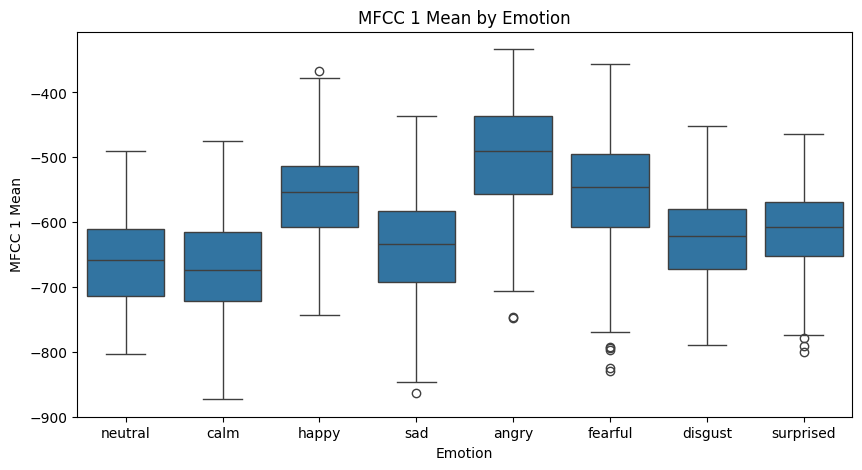

In [42]:
# EDA for features
plt.figure(figsize=(10,5))
sns.boxplot(data=feature_df, x="emotion", y="mfcc_1_mean")
plt.title("MFCC 1 Mean by Emotion")
plt.xlabel("Emotion")
plt.ylabel("MFCC 1 Mean")


Text(0.5, 1.0, 'Correlation Analysis')

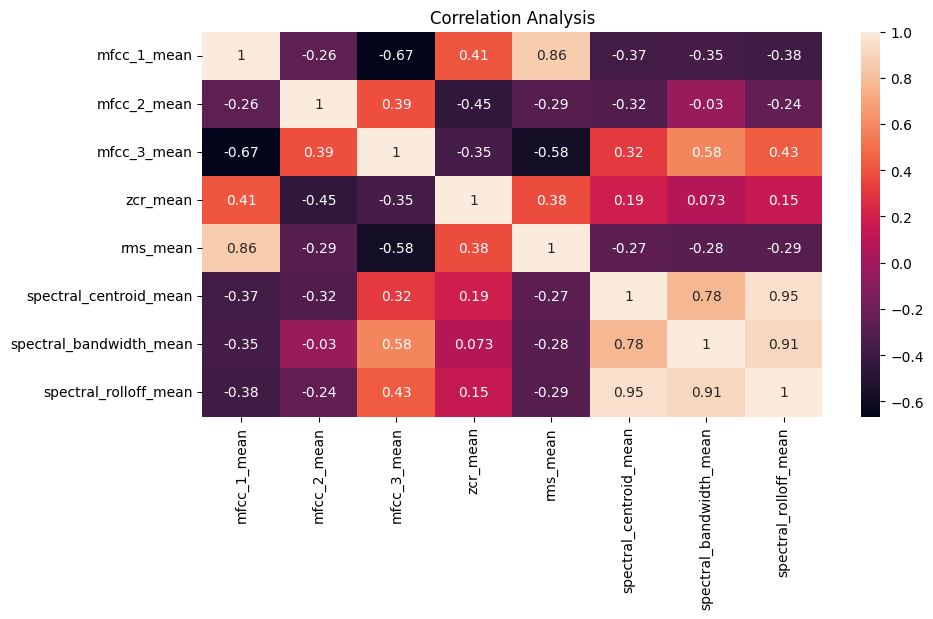

In [43]:
feature_select = ["mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "zcr_mean", "rms_mean", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean"]
plt.figure(figsize=(10,5))
sns.heatmap(feature_df[feature_select].corr(), annot=True)
plt.title("Correlation Analysis")